# DC-Corrected Data Inspection

The raw real-part visibility has a slowly-varying DC pedestal that depends on hour angle (tracking system temperature changes with antenna elevation). We remove this with an **adaptive rolling median** whose window width scales with the local fringe period, ensuring we always average over the same number of fringe cycles regardless of hour angle.

## Why adaptive?

The fringe period is $P_f(h) = 1/|f_f| \propto 1/|\cos h|$: ~20 s at transit, stretching to 60+ s at $h = \pm 70°$. A fixed 100 s window spans ~5 fringe cycles at transit but only ~1.5 cycles at large HA — dangerously close to subtracting real fringe power. An adaptive window that maintains a constant number of fringe periods avoids this.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S,
    NCH_LAT_DEG, NOMINAL_B_EW_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    load_processed_sun_chip_series,
    fringe_period_s,
    PRIMARY_COLOR, SECONDARY_COLOR, TERTIARY_COLOR, QUATERNARY_COLOR,
    NEUTRAL_COLOR, COMPONENT_COLORS,
    SCATTER_S_FINE, LW_FINE, LW_GUIDE, LW_STANDARD, LW_HAIRLINE,
    TEXTWIDTH_IN, TICK_SIZE,
    ALPHA_SHADE_LIGHT,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")

Imports OK.


In [2]:
# --- Load data ---
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
chip_data = load_processed_sun_chip_series(chip_paths)

captures    = chip_data.captures
corr_raw    = captures.corr
corr_std    = captures.corr_std
unix_mid    = captures.unix_mid
ha_deg_arr  = chip_data.ha_deg
ha_rad_arr  = np.deg2rad(ha_deg_arr)
sun_dec     = chip_data.sun_dec_deg
F_SKY_GHZ   = chip_data.f_sky_ghz
F_SKY_HZ    = F_SKY_GHZ * 1e9
DF_HZ       = chip_data.df_hz
chip_slices = chip_data.chip_slices
N_chips     = len(chip_slices)

dec_rad_mean   = np.deg2rad(np.nanmean(sun_dec))
band_mask      = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
for bc in BAD_CHANNELS:
    band_mask[bc] = False
band_center_hz = np.mean(F_SKY_HZ[band_mask])
bad_ch_arr     = np.array(BAD_CHANNELS, dtype=int)

CHIP_COLORS = COMPONENT_COLORS[:N_chips]
print(f"Loaded {corr_raw.shape[0]} captures, {N_chips} chips")

Loaded 8226 captures, 3 chips


## Adaptive rolling median DC correction

For each capture at hour angle $h$, the local fringe period is

$$P_f(h) = \frac{1}{|f_f(h)|} = \frac{\lambda}{\omega_\oplus\, b_{\mathrm{ew}}\,\cos\delta\,|\cos h|}.$$

We set the rolling-median window to a fixed number of fringe periods $N_P$:

$$W(h) = N_P \times P_f(h) = \frac{N_P\,\lambda}{\omega_\oplus\, b_{\mathrm{ew}}\,\cos\delta\,|\cos h|},$$

then convert to capture count via the local cadence. This guarantees the window always spans $N_P$ full fringe cycles, so the median is not biased by the fringe oscillation.

We clamp the window to $[W_{\min},\, W_{\max}]$ captures to avoid degenerate behaviour at $h \to \pm 90°$ (where $P_f \to \infty$) and to ensure enough points for a robust median.

In [3]:
from utils import adaptive_real_dc_correction

# --- Tunable parameters ---
N_PERIODS       = 3.0    # number of fringe periods per window
MIN_WINDOW_CAPS = 7      # minimum window (captures)
MAX_WINDOW_CAPS = 201    # maximum window (captures)

print(f"Adaptive DC correction parameters:")
print(f"  n_periods       = {N_PERIODS}")
print(f"  min_window_caps = {MIN_WINDOW_CAPS}")
print(f"  max_window_caps = {MAX_WINDOW_CAPS}")

Adaptive DC correction parameters:
  n_periods       = 3.0
  min_window_caps = 7
  max_window_caps = 201


In [4]:
# --- Apply adaptive DC correction per chip ---
dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=bad_ch_arr,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=N_PERIODS,
    min_window_caps=MIN_WINDOW_CAPS,
    max_window_caps=MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc
real_offset_chips = dc_result.real_offset_chips
window_caps_concat = dc_result.window_caps

for ci, wc in enumerate(dc_result.window_caps_chips):
    cad = np.median(np.diff(unix_mid[chip_slices[ci]]))
    print(f"  Chip {ci}: {len(wc)} captures, "
          f"window range {wc.min()}–{wc.max()} caps "
          f"({wc.min() * cad:.0f}–{wc.max() * cad:.0f} s)")

print(f"\nTotal DC-corrected captures: {corr_dc.shape[0]}")

  Chip 0: 5514 captures, window range 17–43 caps (45–114 s)
  Chip 1: 403 captures, window range 17–27 caps (43–68 s)
  Chip 2: 2309 captures, window range 17–31 caps (43–78 s)

Total DC-corrected captures: 8226


## Adaptive window size vs hour angle

The window width (in captures) scales as $1/|\cos h|$, clamped to the configured range. This plot shows how the window adapts across the observation.

/tmp/ipykernel_343769/1599960864.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


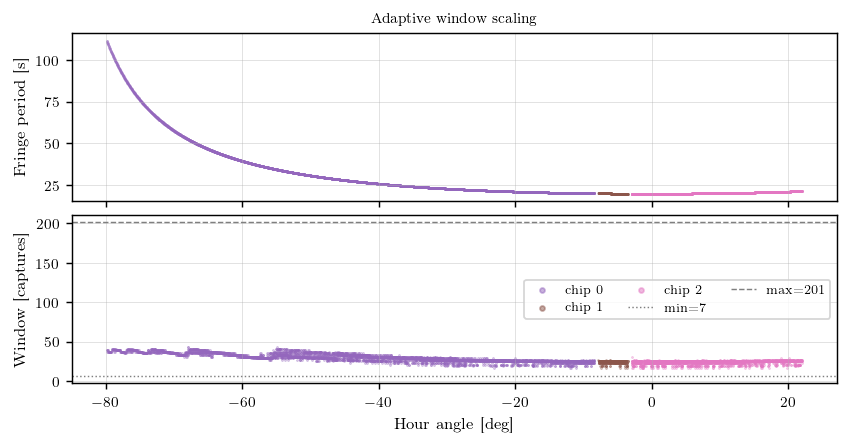

In [5]:
# --- Window size and local fringe period vs HA ---
local_period = fringe_period_s(ha_rad_arr, dec_rad_mean, NOMINAL_B_EW_M, 0.0, band_center_hz)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 3.5), sharex=True,
                         gridspec_kw={"hspace": 0.08})

# (a) Local fringe period
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], local_period[sl], s=0.2, color=CHIP_COLORS[ci],
                    alpha=0.5, rasterized=True)
axes[0].set_ylabel("Fringe period [s]")
axes[0].set_title("Adaptive window scaling", fontsize=TICK_SIZE)

# (b) Window size in captures
for ci, sl in enumerate(chip_slices):
    axes[1].scatter(ha_deg_arr[sl], window_caps_concat[sl], s=0.2, color=CHIP_COLORS[ci],
                    alpha=0.5, rasterized=True, label=f"chip {ci}")
axes[1].axhline(MIN_WINDOW_CAPS, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls=":", label=f"min={MIN_WINDOW_CAPS}")
axes[1].axhline(MAX_WINDOW_CAPS, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls="--", label=f"max={MAX_WINDOW_CAPS}")
axes[1].set_ylabel("Window [captures]")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].legend(fontsize=TICK_SIZE - 1, ncol=3, markerscale=6)

fig.tight_layout()
plt.show()

## DC-corrected visibility vs hour angle

Same four-panel layout as the raw data notebook, now after adaptive DC correction. The real part should oscillate symmetrically about zero at all hour angles.

/tmp/ipykernel_343769/166018001.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


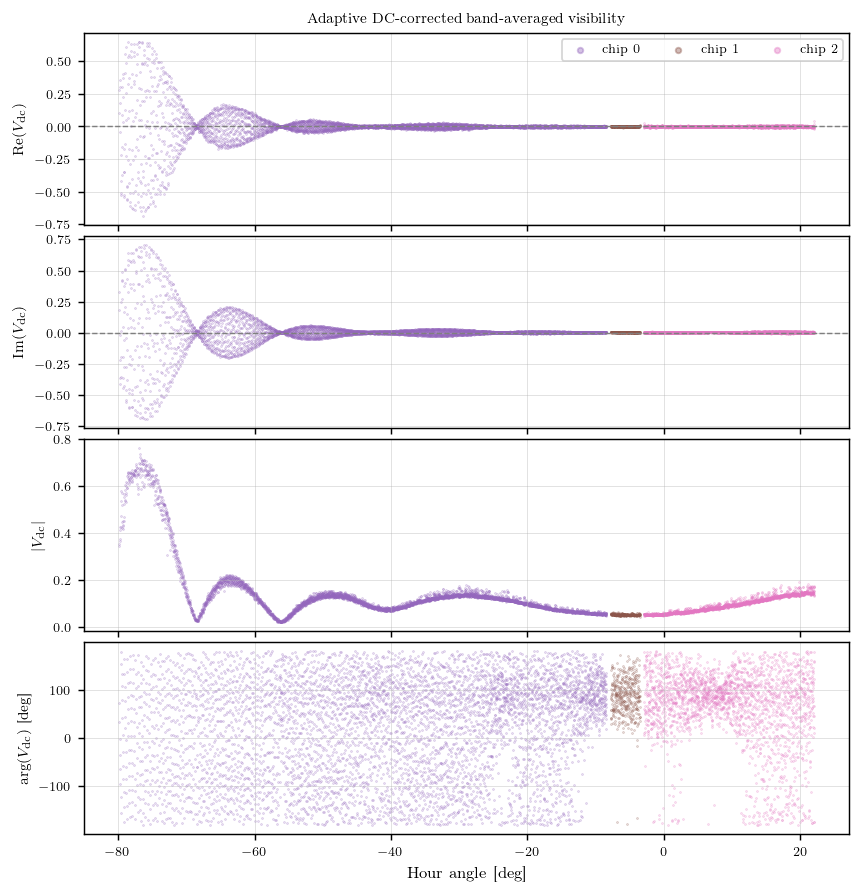

In [6]:
# --- Band-averaged DC-corrected visibility: 4-panel plot ---
corr_dc_band = corr_dc[:, band_mask]

dc_real  = np.nanmean(corr_dc_band.real, axis=1)
dc_imag  = np.nanmean(corr_dc_band.imag, axis=1)
dc_amp   = np.nanmean(np.abs(corr_dc_band), axis=1)
dc_phase = np.angle(np.nanmean(corr_dc_band, axis=1), deg=True)

fig, axes = plt.subplots(4, 1, figsize=(TEXTWIDTH_IN, 8.0), sharex=True,
                         gridspec_kw={"hspace": 0.06})

titles = [r"Re$(V_{\rm dc})$", r"Im$(V_{\rm dc})$", r"$|V_{\rm dc}|$", r"$\arg(V_{\rm dc})$ [deg]"]
data   = [dc_real, dc_imag, dc_amp, dc_phase]

for ax, title, y in zip(axes, titles, data):
    for ci, sl in enumerate(chip_slices):
        ax.scatter(ha_deg_arr[sl], y[sl], s=0.15, color=CHIP_COLORS[ci],
                   alpha=0.4, rasterized=True, label=f"chip {ci}" if ax is axes[0] else None)
    ax.set_ylabel(title, fontsize=TICK_SIZE)
    ax.tick_params(labelsize=TICK_SIZE - 1)
    if "Re" in title or "Im" in title:
        ax.axhline(0, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls="--")

axes[0].legend(fontsize=TICK_SIZE - 1, markerscale=8, ncol=N_chips, loc="upper right")
axes[0].set_title("Adaptive DC-corrected band-averaged visibility", fontsize=TICK_SIZE)
axes[-1].set_xlabel("Hour angle [deg]")
fig.tight_layout()
plt.show()

## Before vs after: raw and corrected Re(V) side by side

Direct comparison of the real part before and after DC correction. The bottom panel shows the subtracted pedestal, which should track the slow elevation-dependent system temperature variation.

/tmp/ipykernel_343769/2563059924.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


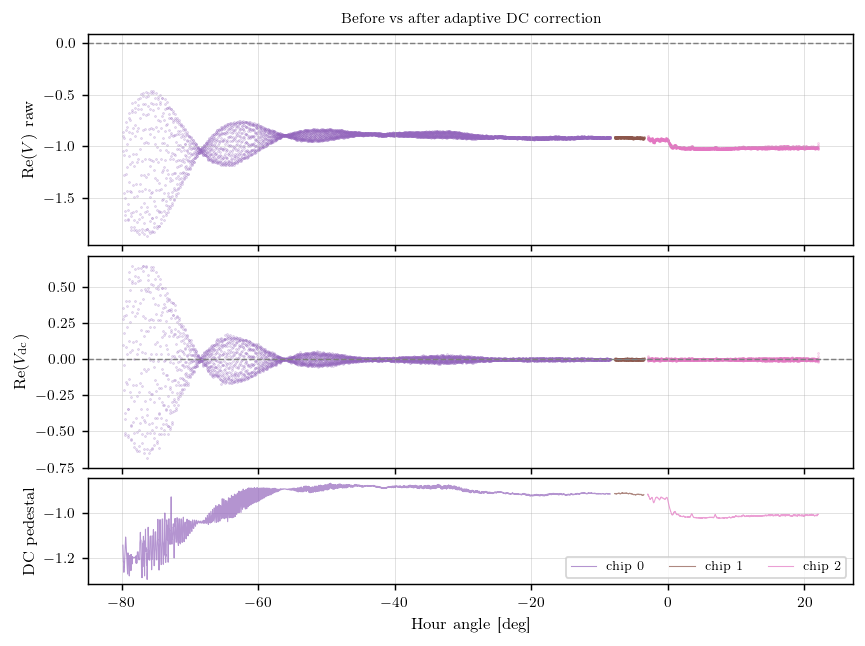

In [7]:
# --- Before / after comparison ---
raw_band_real = np.nanmean(corr_raw[:, band_mask].real, axis=1)
offset_band   = np.nanmean(np.vstack(real_offset_chips)[:, band_mask], axis=1)

fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 5.5), sharex=True,
                         gridspec_kw={"hspace": 0.06, "height_ratios": [2, 2, 1]})

# (a) Raw Re(V)
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], raw_band_real[sl], s=0.15, color=CHIP_COLORS[ci],
                    alpha=0.4, rasterized=True)
axes[0].axhline(0, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls="--")
axes[0].set_ylabel(r"Re$(V)$ raw")
axes[0].set_title("Before vs after adaptive DC correction", fontsize=TICK_SIZE)

# (b) Corrected Re(V)
for ci, sl in enumerate(chip_slices):
    axes[1].scatter(ha_deg_arr[sl], dc_real[sl], s=0.15, color=CHIP_COLORS[ci],
                    alpha=0.4, rasterized=True)
axes[1].axhline(0, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls="--")
axes[1].set_ylabel(r"Re$(V_{\rm dc})$")

# (c) Subtracted pedestal
for ci, sl in enumerate(chip_slices):
    axes[2].plot(ha_deg_arr[sl], offset_band[sl], lw=LW_FINE, color=CHIP_COLORS[ci],
                 alpha=0.7, label=f"chip {ci}")
axes[2].set_ylabel("DC pedestal")
axes[2].set_xlabel("Hour angle [deg]")
axes[2].legend(fontsize=TICK_SIZE - 1, ncol=N_chips)

fig.tight_layout()
plt.show()

## Single-channel view after correction

/tmp/ipykernel_343769/1762067005.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


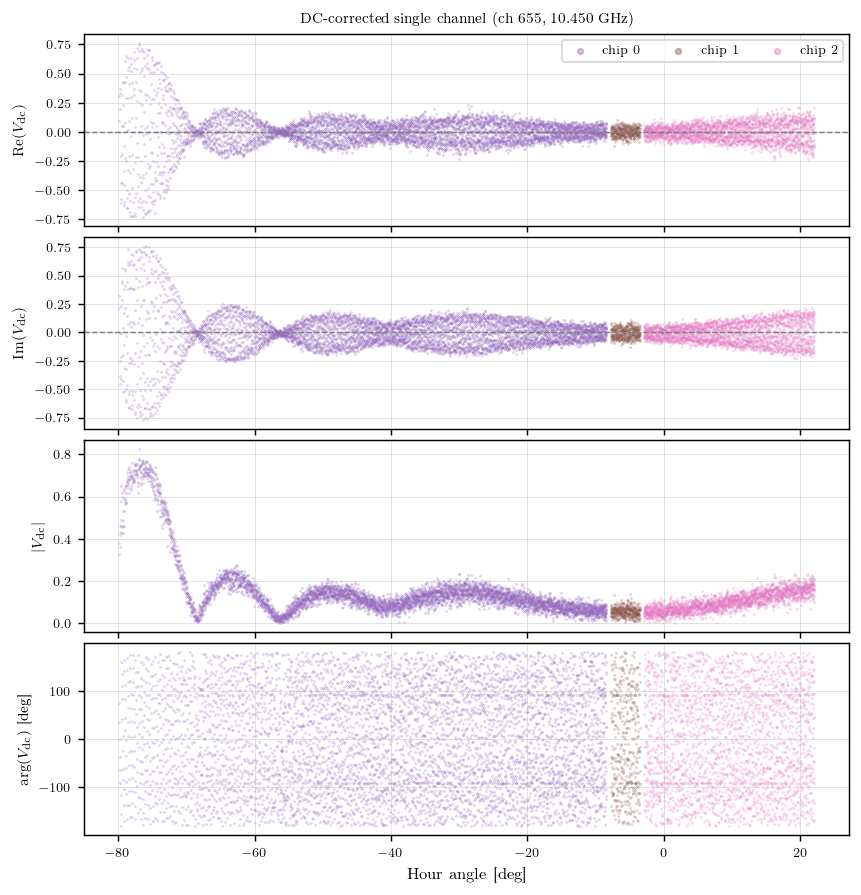

In [8]:
# --- Single-channel DC-corrected view ---
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
f_mid_ghz = F_SKY_GHZ[k_mid]
vis_dc_ch = corr_dc[:, k_mid]

fig, axes = plt.subplots(4, 1, figsize=(TEXTWIDTH_IN, 8.0), sharex=True,
                         gridspec_kw={"hspace": 0.06})

titles = [r"Re$(V_{\rm dc})$", r"Im$(V_{\rm dc})$", r"$|V_{\rm dc}|$", r"$\arg(V_{\rm dc})$ [deg]"]
data   = [vis_dc_ch.real, vis_dc_ch.imag, np.abs(vis_dc_ch), np.angle(vis_dc_ch, deg=True)]

for ax, title, y in zip(axes, titles, data):
    for ci, sl in enumerate(chip_slices):
        ax.scatter(ha_deg_arr[sl], y[sl], s=0.15, color=CHIP_COLORS[ci],
                   alpha=0.4, rasterized=True, label=f"chip {ci}" if ax is axes[0] else None)
    ax.set_ylabel(title, fontsize=TICK_SIZE)
    ax.tick_params(labelsize=TICK_SIZE - 1)
    if "Re" in title or "Im" in title:
        ax.axhline(0, color=NEUTRAL_COLOR, lw=LW_GUIDE, ls="--")

axes[0].legend(fontsize=TICK_SIZE - 1, markerscale=8, ncol=N_chips, loc="upper right")
axes[0].set_title(f"DC-corrected single channel (ch {k_mid}, {f_mid_ghz:.3f} GHz)", fontsize=TICK_SIZE)
axes[-1].set_xlabel("Hour angle [deg]")
fig.tight_layout()
plt.show()